# Week 5: Comprehensive Data Science Project

## Breast Cancer Classification Using Machine Learning

### Comprehensive Data Analysis, Statistical Analysis, Machine Learning and Strategic Recommendations

Name:
Internship:
Week: 5
Dataset: sklearn.datasets.load_breast_cancer

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from scipy.stats import chi2_contingency

In [2]:
data = load_breast_cancer()

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 1. Dataset Loading and Understanding

In [3]:
print("Number of samples:", data.data.shape[0])
print("Number of features:", data.data.shape[1])

print("\nFeature names:")
print(data.feature_names)

print("\nTarget names:")
print(data.target_names)

Number of samples: 569
Number of features: 30

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
['malignant' 'benign']


In [4]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df["diagnosis"] = df["target"].map({
    0: "malignant",
    1: "benign"
})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [6]:
print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape:
(569, 32)

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave poi

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 2. Exploratory Data Analysis

In [8]:
print(df["diagnosis"].value_counts())

diagnosis
benign       357
malignant    212
Name: count, dtype: int64


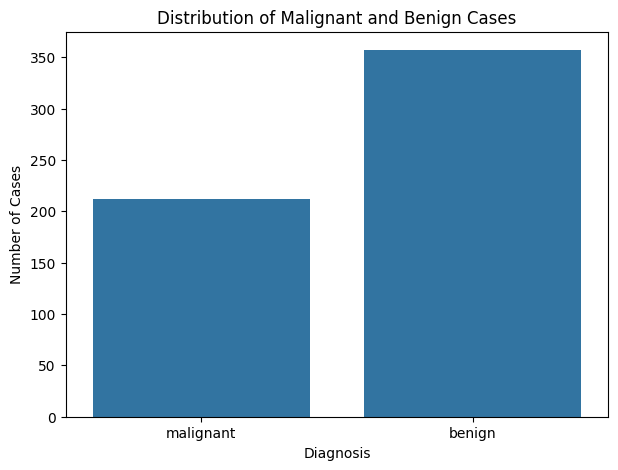

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="diagnosis")

plt.title("Distribution of Malignant and Benign Cases")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Cases")

plt.show()

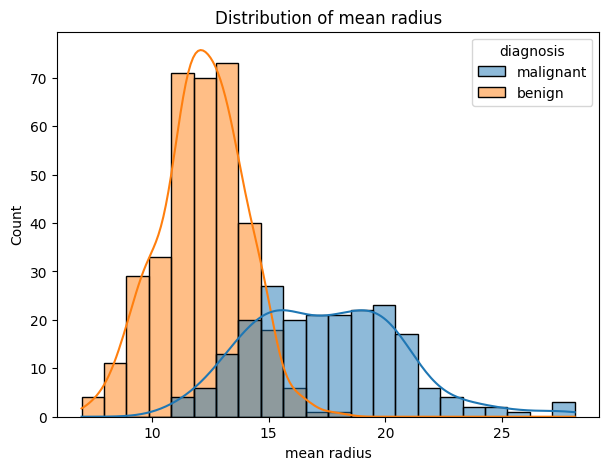

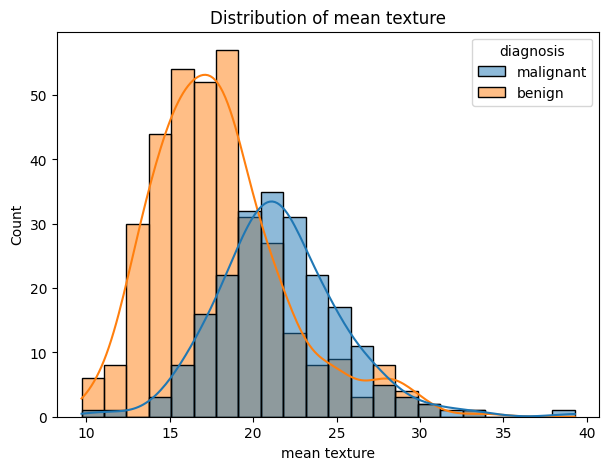

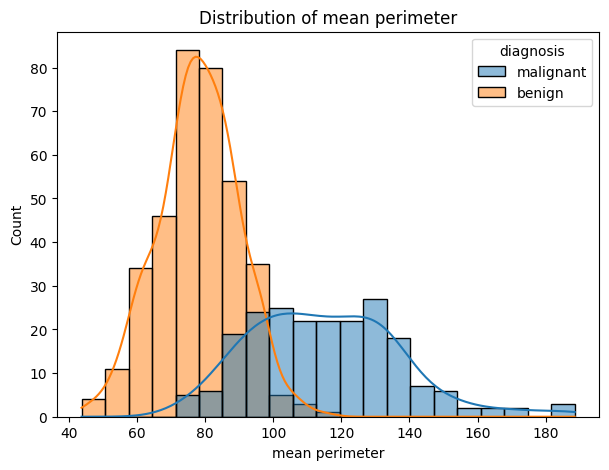

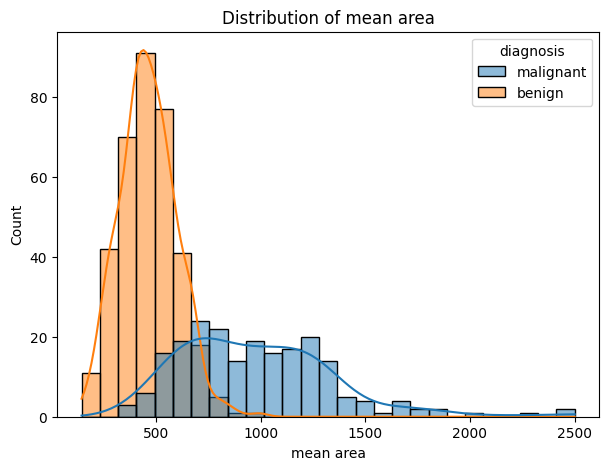

In [10]:
features_to_plot = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area"
]

for feature in features_to_plot:
    plt.figure(figsize=(7,5))

    sns.histplot(
        data=df,
        x=feature,
        hue="diagnosis",
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.show()

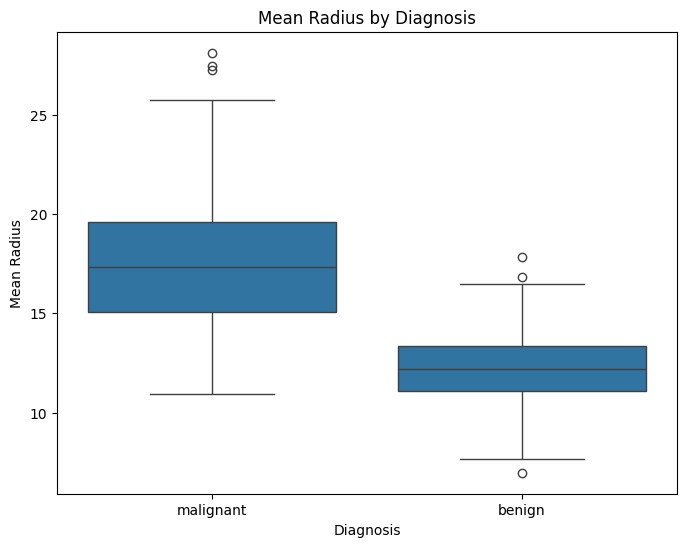

In [11]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="diagnosis",
    y="mean radius"
)

plt.title("Mean Radius by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean Radius")

plt.show()

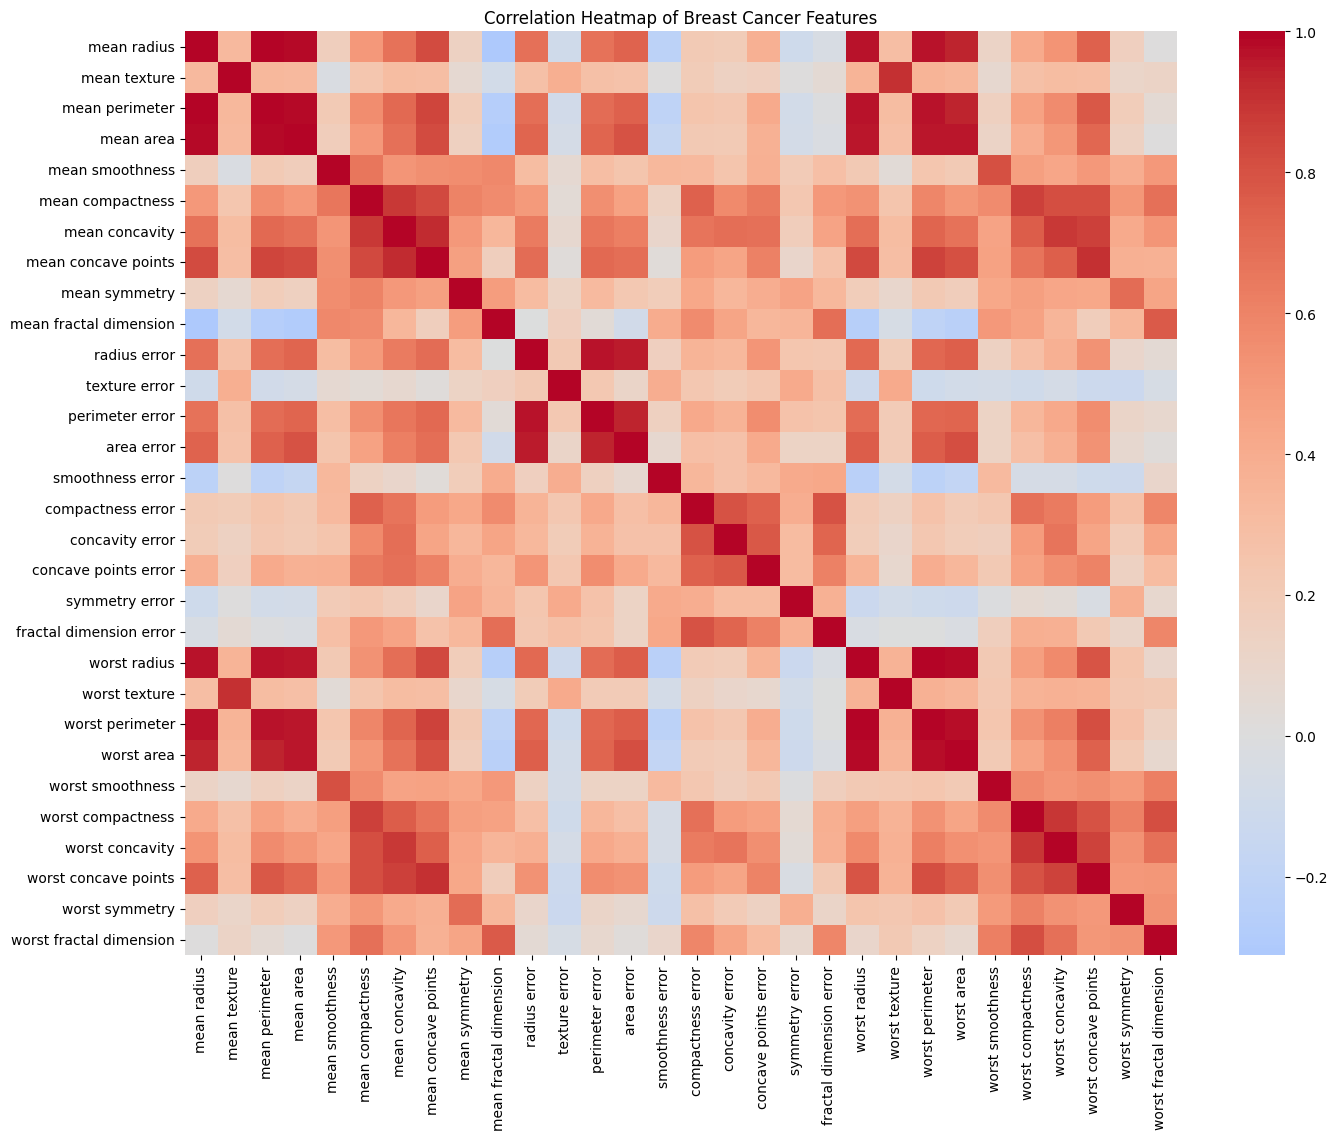

In [12]:
plt.figure(figsize=(16,12))

correlation = df[data.feature_names].corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Breast Cancer Features")

plt.show()

In [13]:
correlation_pairs = correlation.unstack()

correlation_pairs = correlation_pairs[
    correlation_pairs != 1
]

correlation_pairs.abs().sort_values(
    ascending=False
).head(20)

mean radius      mean perimeter     0.997855
mean perimeter   mean radius        0.997855
worst perimeter  worst radius       0.993708
worst radius     worst perimeter    0.993708
mean radius      mean area          0.987357
mean area        mean radius        0.987357
                 mean perimeter     0.986507
mean perimeter   mean area          0.986507
worst radius     worst area         0.984015
worst area       worst radius       0.984015
                 worst perimeter    0.977578
worst perimeter  worst area         0.977578
radius error     perimeter error    0.972794
perimeter error  radius error       0.972794
worst perimeter  mean perimeter     0.970387
mean perimeter   worst perimeter    0.970387
mean radius      worst radius       0.969539
worst radius     mean radius        0.969539
mean perimeter   worst radius       0.969476
worst radius     mean perimeter     0.969476
dtype: float64

## 3. Statistical Analysis and Hypothesis Testing

In [14]:
median_radius = df["mean radius"].median()

df["radius_group"] = np.where(
    df["mean radius"] >= median_radius,
    "High Radius",
    "Low Radius"
)

contingency_table = pd.crosstab(
    df["radius_group"],
    df["diagnosis"]
)

print(contingency_table)

diagnosis     benign  malignant
radius_group                   
High Radius       90        195
Low Radius       267         17


In [15]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 234.54477585836327
p-value: 6.084766364093077e-53


In [16]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
    print("There is a statistically significant association.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence of a significant association.")

Reject the null hypothesis.
There is a statistically significant association.


## 4. Machine Learning Model Development

In [17]:
X = df[data.feature_names]
y = df["target"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
logistic_model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

In [21]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred
)

logistic_recall = recall_score(
    y_test,
    logistic_pred
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred
)

print("Logistic Regression")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1 Score:", logistic_f1)

Logistic Regression
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112


In [22]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(X_test)

In [23]:
tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

tree_precision = precision_score(
    y_test,
    tree_pred
)

tree_recall = recall_score(
    y_test,
    tree_pred
)

tree_f1 = f1_score(
    y_test,
    tree_pred
)

print("Decision Tree")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1 Score:", tree_f1)

Decision Tree
Accuracy: 0.9122807017543859
Precision: 0.9558823529411765
Recall: 0.9027777777777778
F1 Score: 0.9285714285714286


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

In [25]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Random Forest
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


In [26]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517


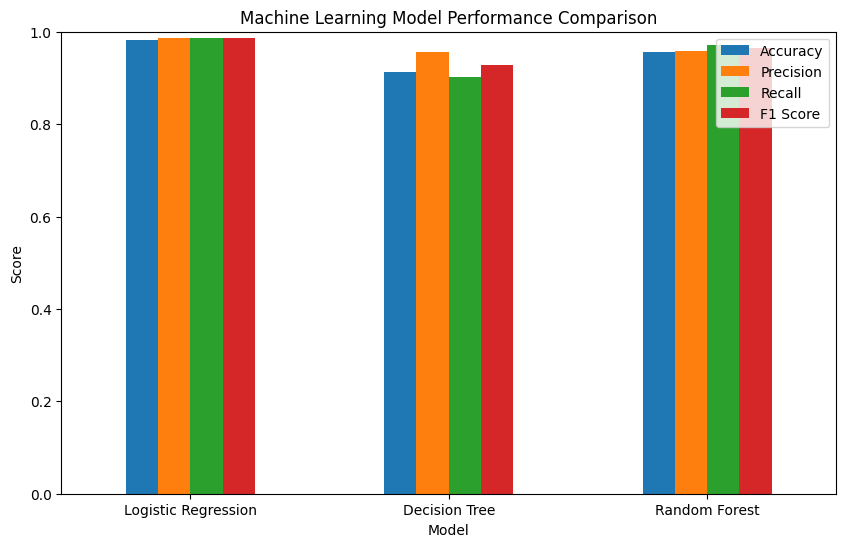

In [27]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [28]:
best_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object


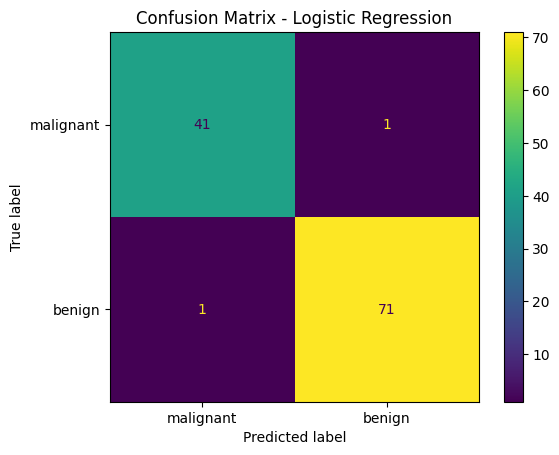

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=data.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [39]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [31]:
feature_importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


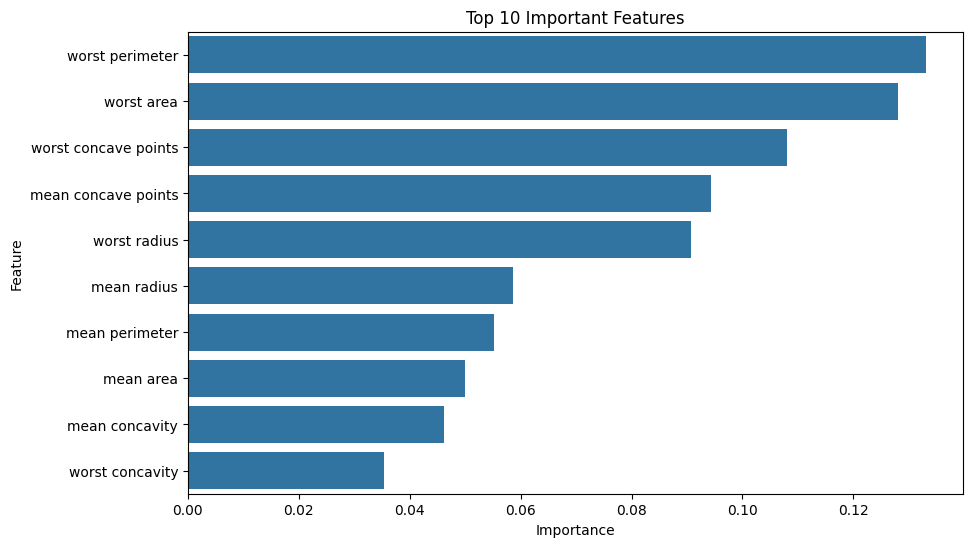

In [32]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 5. Results and Key Findings

### 5.1 Dataset Findings

The Breast Cancer dataset contains 569 samples and 30 numerical features. The target variable contains two classes: malignant and benign.

The dataset contains no missing values and no duplicate rows. The exploratory analysis shows differences in several measured characteristics between malignant and benign cases.

The analysis also indicates that several features are strongly correlated with one another, particularly measurements related to radius, perimeter, area, and concave points.

### 5.2 Exploratory Data Analysis Findings

The class distribution shows 357 benign cases and 212 malignant cases. Therefore, the dataset contains more benign than malignant observations.

The distribution plots and boxplots show differences in important numerical features between the two diagnosis groups. The correlation analysis also shows strong relationships among several measurements.

### 5.3 Statistical Analysis Findings

A Chi-square test was conducted to examine the association between the mean radius group and diagnosis.

The chi-square statistic was 234.545 and the p-value was approximately 6.08 × 10⁻⁵³.

Because the p-value is much smaller than the significance level of 0.05, the null hypothesis was rejected.

Therefore, there is statistically significant evidence of an association between the mean radius group and diagnosis in this dataset.

In [34]:
print("Chi-square statistic:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject the null hypothesis.")
    print("Conclusion: There is a statistically significant association between mean radius group and diagnosis.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Conclusion: There is not enough evidence of a statistically significant association.")

Chi-square statistic: 234.54477585836327
p-value: 6.084766364093077e-53
Decision: Reject the null hypothesis.
Conclusion: There is a statistically significant association between mean radius group and diagnosis.


## 6. Machine Learning Results

### 6.1 Model Performance Comparison

Three classification models were evaluated: Logistic Regression, Decision Tree, and Random Forest.

The models were compared using accuracy, precision, recall, and F1 score. These metrics provide a broader evaluation of classification performance rather than relying only on accuracy.

In [35]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517


In [36]:
print("Best Model Based on F1 Score:")
print(best_model)

Best Model Based on F1 Score:
Model        Logistic Regression
Accuracy                0.982456
Precision               0.986111
Recall                  0.986111
F1 Score                0.986111
Name: 0, dtype: object


### 6.2 Best Model

Based on the F1 score, Logistic Regression was selected as the best-performing model.

Logistic Regression achieved an accuracy of 98.25%, precision of 98.61%, recall of 98.61%, and an F1 score of 98.61%.

Among the three evaluated models, Logistic Regression achieved the highest F1 score and accuracy. Therefore, it was selected as the best-performing model for this dataset and analysis.

### 6.3 Confusion Matrix Analysis

The confusion matrix shows the number of correctly and incorrectly classified observations for each class.

It provides a detailed view of the model's classification performance and helps identify false positive and false negative predictions.

### 6.4 Classification Report

The classification report provides precision, recall, F1 score, and support for each diagnosis class.

Logistic Regression achieved an overall accuracy of approximately 98.25% on the test dataset. It also achieved approximately 98.61% precision, 98.61% recall, and 98.61% F1 score.

These results indicate that Logistic Regression performed strongly on the test data for this classification task.

### 6.5 Feature Importance Findings

Random Forest feature importance was used to identify which features contributed most strongly to the Random Forest model's predictions.

The most important features included worst perimeter, worst area, worst concave points, mean concave points, and worst radius.

These features were particularly influential within the Random Forest model. Feature importance represents predictive contribution within this model and should not be interpreted as proof of causal relationships.

## 7. Strategic Recommendations

### Recommendation 1: Use Machine Learning as a Research Support Tool

The results show that machine-learning models can classify observations in this benchmark dataset with strong performance. Such models can be explored as decision-support or research tools, subject to appropriate validation and expert oversight.

### Recommendation 2: Investigate Important Predictive Features

The Random Forest feature-importance analysis identified measurements such as worst perimeter, worst area, worst concave points, and worst radius as highly influential within the Random Forest model. These features can be investigated further in future analyses to understand their predictive contribution.

### Recommendation 3: Evaluate Multiple Performance Metrics

Model selection should not depend only on accuracy. Precision, recall, and F1 score should also be considered because they provide additional information about classification errors and class-specific performance.

### Recommendation 4: Validate the Model Using Independent Data

Before considering practical or clinical applications, the model should be evaluated using independent datasets from different sources and populations. External validation would help determine whether the observed performance generalizes beyond this benchmark dataset.

### Recommendation 5: Maintain Human and Expert Oversight

Machine-learning predictions should not be treated as independent medical diagnoses. Any real-world application would require qualified professionals, appropriate validation, ethical safeguards, and regulatory consideration.

## 8. Potential Research Impact

### 8.1 Research Outcomes

This project demonstrates an end-to-end data science workflow using a publicly available breast cancer classification dataset.

The analysis combines exploratory data analysis, statistical hypothesis testing, machine-learning classification, model evaluation, and feature-importance analysis.

The results demonstrate how data science methods can be used to identify patterns in structured data and develop predictive classification models.

## 9. Limitations

### Limitations of the Study

1. The analysis uses a benchmark dataset rather than newly collected real-world data.

2. The dataset contains a limited number of observations compared with the diversity that may exist in real-world populations.

3. The machine-learning results depend on the features and observations contained in the dataset.

4. The analysis uses a single train-test split, so model performance may vary with different data splits.

5. Feature importance from a Random Forest model indicates predictive usefulness within the model and should not automatically be interpreted as causal importance.

6. The model should not be considered a clinically validated diagnostic system.

## 10. Future Improvements

### Future Work

1. Collect and evaluate larger and more diverse datasets.

2. Perform k-fold cross-validation to obtain more robust performance estimates.

3. Perform hyperparameter tuning for the machine-learning models.

4. Evaluate additional classification algorithms.

5. Test the final model on an independent external dataset.

6. Investigate explainable AI techniques to better understand model predictions.

7. Develop an interactive dashboard for presenting model results.

8. Continuously monitor model performance if the system is eventually deployed in a real-world environment.

## 11. Conclusion

This project presented a comprehensive data science analysis of the Breast Cancer dataset available through scikit-learn.

The project followed an end-to-end workflow including data loading, data understanding, exploratory data analysis, statistical hypothesis testing, feature analysis, machine-learning model development, model comparison, and evaluation.

Three classification algorithms were evaluated: Logistic Regression, Decision Tree, and Random Forest.

Among the three models, Logistic Regression achieved the best performance, with an accuracy of approximately 98.25%, precision of approximately 98.61%, recall of approximately 98.61%, and an F1 score of approximately 98.61%.

The Random Forest feature-importance analysis identified several influential features, including worst perimeter, worst area, worst concave points, mean concave points, and worst radius.

The statistical analysis also found a statistically significant association between the mean radius group and diagnosis.

Overall, the project demonstrates how exploratory analysis, statistical testing, and machine-learning techniques can be combined in an end-to-end data science workflow. However, the results are based on a benchmark dataset and should not be interpreted as a clinically validated diagnostic system.

## 12. References

1. Scikit-learn documentation – Breast Cancer Wisconsin dataset.

2. Scikit-learn documentation – Classification algorithms and evaluation metrics.

3. Python documentation – Python programming language.

4. Pandas documentation – Data manipulation and analysis.

5. Matplotlib documentation – Data visualization.

6. Seaborn documentation – Statistical data visualization.

7. SciPy documentation – Statistical analysis and hypothesis testing.

## 13. Appendix

### Appendix A: Important Code

The appendix contains selected Python code snippets used for dataset loading, preprocessing, statistical analysis, model training, model evaluation, and feature-importance analysis.